In [25]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [26]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

csv_files = list(RAW_DATA_DIR.glob("*.csv"))
xlsx_files = list(RAW_DATA_DIR.glob("*.xlsx"))

if csv_files:
    file = csv_files[0]
    df = pd.read_csv(file)
else:
    file = xlsx_files[0]
    df = pd.read_excel(file)

print(file.name)

laramee26openBankTransactionData.xlsx


In [27]:
df.head()

,Transaction Number,Transaction Date,Transaction Type,Transaction Description,Debit Amount,Credit Amount,Balance,Category,Location City,Location Country
0,1,25/07/2022,BP,SAVE THE CHANGE,3.11,NaN,541.43,Savings,Nottingham,UK
1,2,25/07/2022,DEB,LIDL GB NOTTINGHA,15.02,NaN,544.54,Groceries,Nottingham,UK
2,3,25/07/2022,DEB,NON-GBP PURCH FEE,0.50,NaN,559.56,Others,Nottingham,UK
3,4,25/07/2022,DEB,NON-GBP TRANS FEE,0.37,NaN,560.06,Others,Nottingham,UK
4,5,25/07/2022,DEB,TRAVELIUM LLC,12.59,NaN,560.43,NaN,NaN,NaN


In [28]:
df.tail()

,Transaction Number,Transaction Date,Transaction Type,Transaction Description,Debit Amount,Credit Amount,Balance,Category,Location City,Location Country
6562,6563,28/07/2015,DEB,Amazon Svcs Europe,5.49,NaN,7187.57,Amazon,Swansea,UK
6563,6564,28/07/2015,BP,SAVE THE CHANGE,1.10,NaN,7193.06,Savings,Swansea,UK
6564,6565,27/07/2015,DEB,Amazon UK Marketpl,6.39,NaN,7194.16,Amazon,Swansea,UK
6565,6566,27/07/2015,DEB,JS ONLINE GROCERY,316.51,NaN,7200.55,Groceries,Swansea,UK
6566,6567,27/07/2015,FPO,ALAN HOLLAND,1000.00,NaN,7517.06,Services,Swansea,UK


In [29]:
df.shape

(6567, 10)

In [30]:
df.columns.tolist()

['Transaction Number',
 'Transaction Date',
 'Transaction Type',
 'Transaction Description',
 'Debit Amount',
 'Credit Amount',
 'Balance',
 'Category',
 'Location City',
 'Location Country']

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6567 entries, 0 to 6566
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction Number       6567 non-null   int64  
 1   Transaction Date         6567 non-null   object 
 2   Transaction Type         6506 non-null   str    
 3   Transaction Description  6567 non-null   object 
 4   Debit Amount             6122 non-null   float64
 5   Credit Amount            445 non-null    float64
 6   Balance                  6567 non-null   float64
 7   Category                 6543 non-null   str    
 8   Location City            5895 non-null   str    
 9   Location Country         5881 non-null   str    
dtypes: float64(3), int64(1), object(2), str(4)
memory usage: 513.2+ KB


## Column Dictionary

| Column | Meaning |
|--------|---------|
| **Transaction Number** | Unique sequential ID for each transaction in the dataset. |
| **Transaction Date** | Date the transaction was posted (stored as text / mixed formats in the raw file, e.g. `DD/MM/YYYY`). |
| **Transaction Type** | Bank posting code for how the money moved (e.g. `DEB` debit card, `BP` bill payment, `DD` direct debit, `BGC` bank giro credit). |
| **Transaction Description** | Free-text merchant / payee / narrative from the bank statement. |
| **Debit Amount** | Money leaving the account. Present for outgoing transactions; missing when the row is a credit. |
| **Credit Amount** | Money entering the account. Present for incoming transactions; missing when the row is a debit. |
| **Balance** | Account balance after this transaction was applied. |
| **Category** | Spending / income category label (e.g. Groceries, Savings, Bills). |
| **Location City** | City associated with the transaction, when available. |
| **Location Country** | Country associated with the transaction, when available. |

**Note:** Debit and Credit are mutually exclusive — each row has a value in one of them, never both.

Summary Stats

Numerical

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction Number,6567.0,3284.000000,1895.873941,1.00,1642.50,3284.00,4925.50,6567.00
Debit Amount,6122.0,83.498680,1107.100490,0.01,3.00,12.12,35.56,84000.00
Credit Amount,445.0,1130.793910,4173.038020,0.01,5.71,246.00,1004.43,83840.54
Balance,6567.0,8409.749756,6839.368572,65.61,1872.98,7551.85,14381.42,94066.01


Categoricals

In [33]:
df.describe(include="object").T

,count,unique,top,freq
Transaction Date,6567,1660,21/10/2019,28
Transaction Type,6506,13,DEB,3268
Transaction Description,6567,908,SAVE THE CHANGE,1165
Category,6543,30,Savings,1249
Location City,5895,58,Swansea,3144
Location Country,5881,16,UK,5826


## Missing Values

Includes column-level missing counts and Location City vs Country consistency (city without country, or country without city).


In [41]:
missing = (
    df.isnull()
      .sum()
      .to_frame("Missing")
)

missing["Percent"] = (
    missing["Missing"] / len(df) * 100
)

display(missing.sort_values("Missing", ascending=False))

# Location City vs Country consistency
city_null = df["Location City"].isna()
country_null = df["Location Country"].isna()

location_patterns = pd.DataFrame({
    "Pattern": [
        "Both present",
        "Both missing",
        "City missing, Country present",
        "City present, Country missing",
    ],
    "Count": [
        int((~city_null & ~country_null).sum()),
        int((city_null & country_null).sum()),
        int((city_null & ~country_null).sum()),
        int((~city_null & country_null).sum()),
    ],
})
location_patterns["Percent"] = location_patterns["Count"] / len(df) * 100

print("\nLocation City vs Country consistency:")
display(location_patterns)

city_without_country = df.loc[
    df["Location City"].notna() & df["Location Country"].isna(),
    [
        "Transaction Number",
        "Transaction Date",
        "Transaction Description",
        "Category",
        "Location City",
        "Location Country",
    ],
]
print(f"\nCity present, Country missing: {len(city_without_country)}")
if len(city_without_country):
    city_country_lookup = (
        df.loc[
            df["Location City"].notna() & df["Location Country"].notna(),
            ["Location City", "Location Country"],
        ]
        .value_counts()
        .reset_index(name="freq")
    )
    affected_cities = city_without_country["Location City"].value_counts().rename(
        "rows_missing_country"
    )
    suggested = (
        city_country_lookup
        .sort_values("freq", ascending=False)
        .drop_duplicates(subset=["Location City"], keep="first")
        .set_index("Location City")["Location Country"]
    )
    city_fix_candidates = (
        affected_cities
        .to_frame()
        .join(suggested.rename("most_common_country"), how="left")
    )
    display(city_without_country)
    display(city_fix_candidates)

country_without_city = df.loc[
    df["Location City"].isna() & df["Location Country"].notna(),
    [
        "Transaction Number",
        "Transaction Date",
        "Transaction Description",
        "Category",
        "Location City",
        "Location Country",
    ],
]
print(f"\nCity missing, Country present: {len(country_without_city)}")
if len(country_without_city):
    display(country_without_city)


,Missing,Percent
Credit Amount,6122,93.223694
Location Country,686,10.446170
Location City,672,10.232983
Debit Amount,445,6.776306
Transaction Type,61,0.928887
Category,24,0.365464
Transaction Date,0,0.000000
Transaction Number,0,0.000000
Transaction Description,0,0.000000
Balance,0,0.000000



Location City vs Country consistency:


,Pattern,Count,Percent
0,Both present,5881,89.553830
1,Both missing,672,10.232983
2,"City missing, Country present",0,0.000000
3,"City present, Country missing",14,0.213187



City present, Country missing: 14


,Transaction Number,Transaction Date,Transaction Description,Category,Location City,Location Country
1638,1639,23/04/2021,SAINSBURYS S/MKT,Groceries,Nottingham,NaN
1651,1652,19/04/2021,T K MAXX,Other Shopping,Nottingham,NaN
1653,1654,19/04/2021,WILKO RETAIL LIMIT,Other Shopping,Nottingham,NaN
2892,2893,16/12/2019,CRYSTAL CLEAR,Other Shopping,Bristol,NaN
3177,3178,27/08/2019,BRS WDF MAIN,Other Shopping,Bristol,NaN
3581,3582,29/04/2019,HATHWAY HOUSE ACCO,Hotels,Bristol,NaN
3846,3847,2019-07-01 00:00:00,GWR BRISTOL TM SST,Travel,Bristol,NaN
4863,4864,23/08/2017,LNK TESCO BLEN CRT,Cash,Bristol,NaN
5056,5057,30/05/2017,LNK RAIL BRISTOL T,Cash,Bristol,NaN
5744,5745,27/06/2016,J B PEARCE LTD,Travel,Bristol,NaN


,rows_missing_country,most_common_country
Location City,,
Bristol,10,UK
Nottingham,3,UK
Swansea,1,UK



City missing, Country present: 0


## Duplicate Records

Checks exact duplicate rows and categorical labels that differ only by capitalization (e.g. `Swansea` vs `swansea`).

In [40]:
duplicate_mask = df.duplicated(keep=False)
duplicates = int(df.duplicated().sum())
print(f"Duplicate Rows: {duplicates}")

if duplicates:
    display(df.loc[duplicate_mask].sort_values(df.columns.tolist()).reset_index(drop=True))

case_check_cols = [
    "Transaction Type",
    "Category",
    "Location City",
    "Location Country",
]

case_collisions = []

for col in case_check_cols:
    values = df[col].dropna().astype(str).str.strip()
    groups = {}

    for value in values.unique():
        groups.setdefault(value.casefold(), set()).add(value)

    for key, variants in groups.items():
        if len(variants) > 1:
            case_collisions.append({
                "Column": col,
                "Canonical": key,
                "Variants": sorted(variants),
                "Variant Count": len(variants),
                "Row Count": int(values.str.casefold().eq(key).sum()),
            })

if case_collisions:
    print(f"\nDuplicate categorical labels (case-only): {len(case_collisions)}")
    display(pd.DataFrame(case_collisions))
else:
    print("\nDuplicate categorical labels (case-only): 0")

Duplicate Rows: 0

Duplicate categorical labels (case-only): 2


,Column,Canonical,Variants,Variant Count,Row Count
0,Location City,nottingham,"[Nottingham, nottingham]",2,2502
1,Location City,swansea,"[Swansea, swansea]",2,3162


Data Types

In [16]:
df.dtypes

Transaction Number           int64
Transaction Date            object
Transaction Type               str
Transaction Description     object
Debit Amount               float64
Credit Amount              float64
Balance                    float64
Category                       str
Location City                  str
Location Country               str
dtype: object

Unique Values

In [17]:
unique = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})

unique

,Unique Values,Data Type
Transaction Number,6567,int64
Transaction Date,1660,object
Transaction Type,13,str
Transaction Description,908,object
Debit Amount,2035,float64
Credit Amount,267,float64
Balance,6507,float64
Category,30,str
Location City,58,str
Location Country,16,str


Numerical Feats

In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['Transaction Number', 'Debit Amount', 'Credit Amount', 'Balance'], dtype='str')

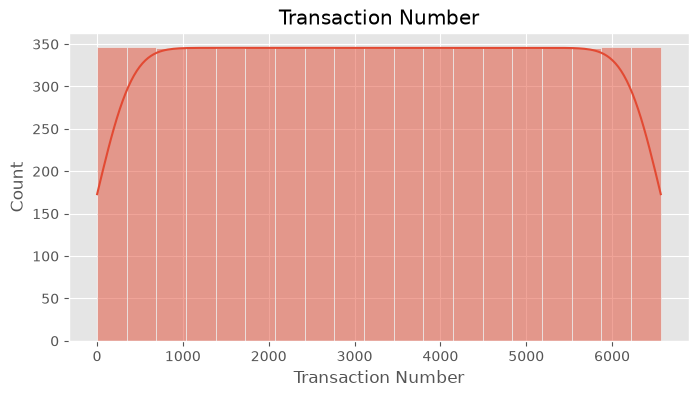

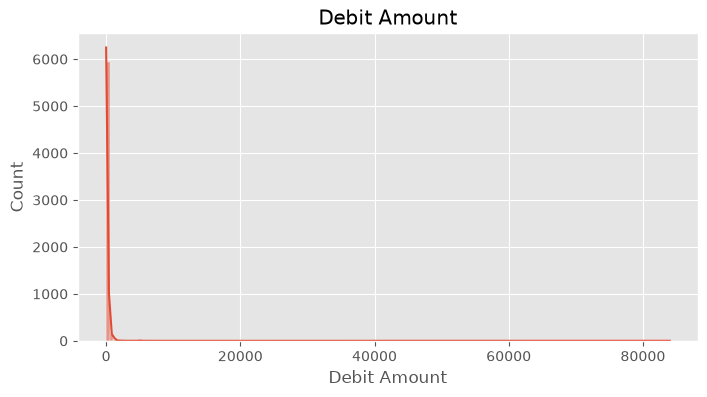

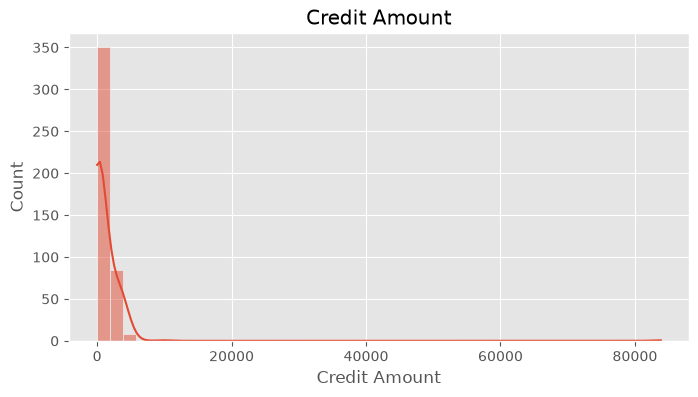

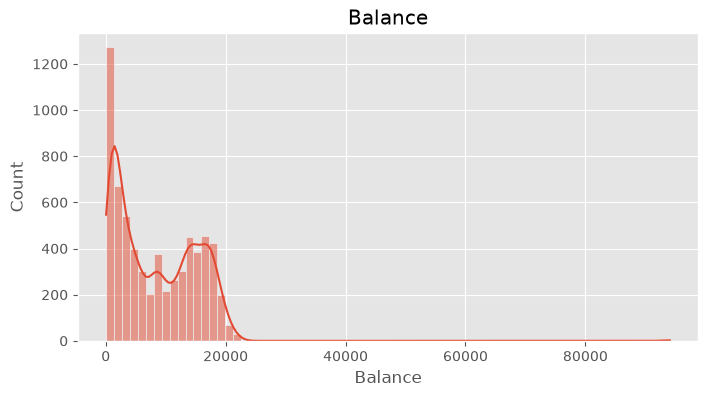

In [19]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

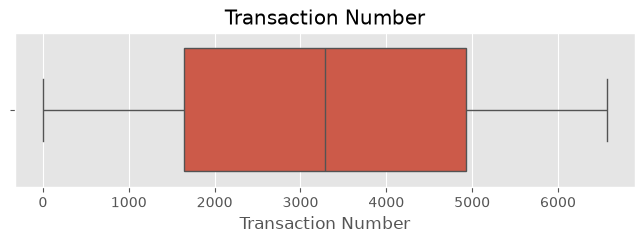

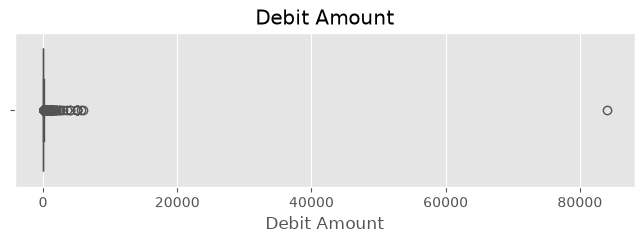

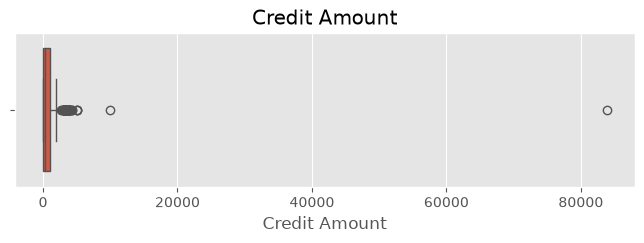

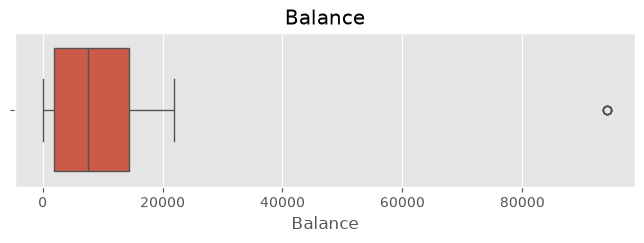

In [20]:
for col in numeric_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

Categorical Features

In [21]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['Transaction Date', 'Transaction Type', 'Transaction Description',
       'Category', 'Location City', 'Location Country'],
      dtype='str')

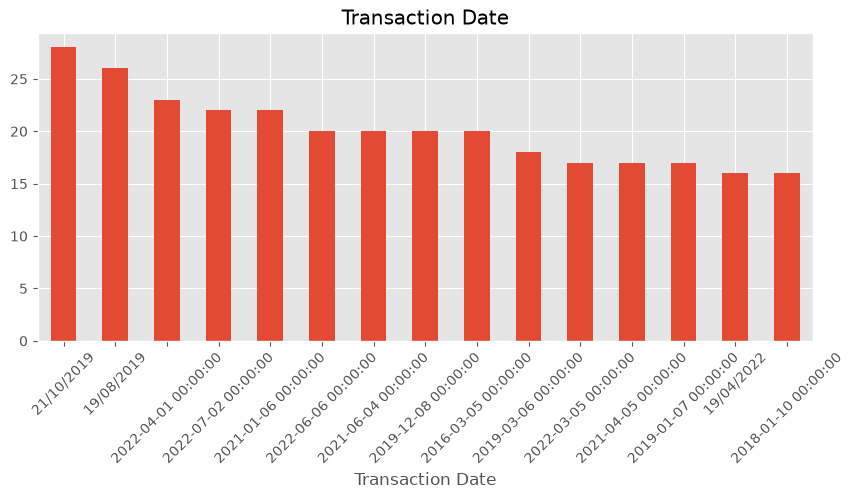

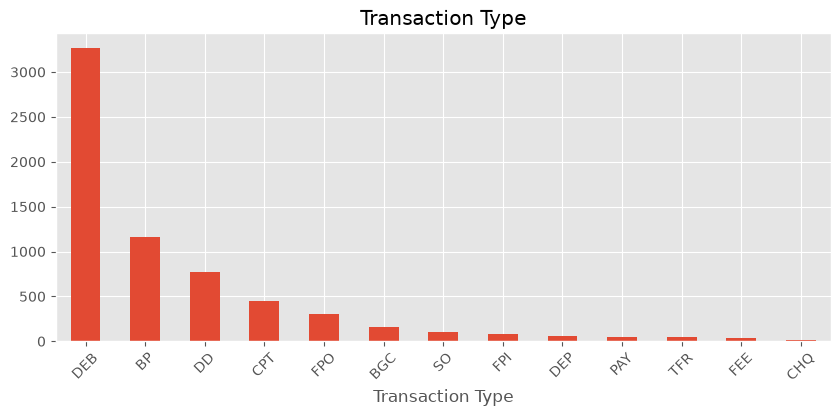

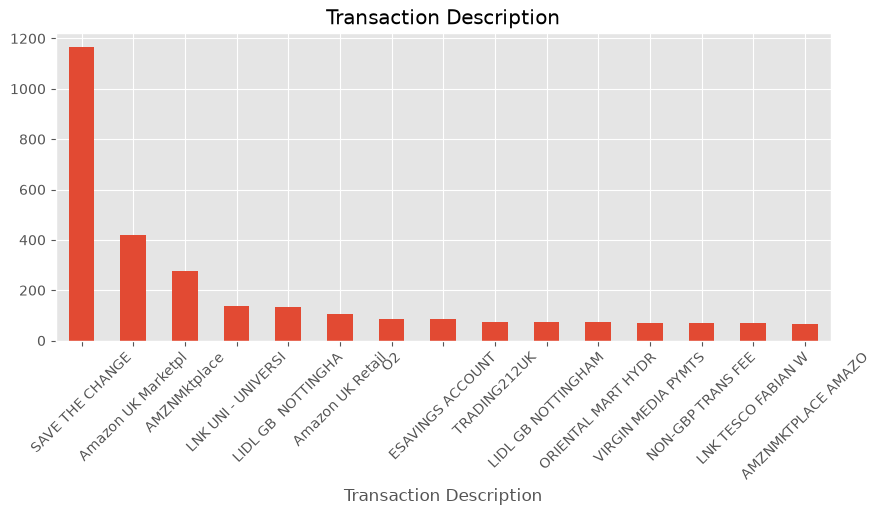

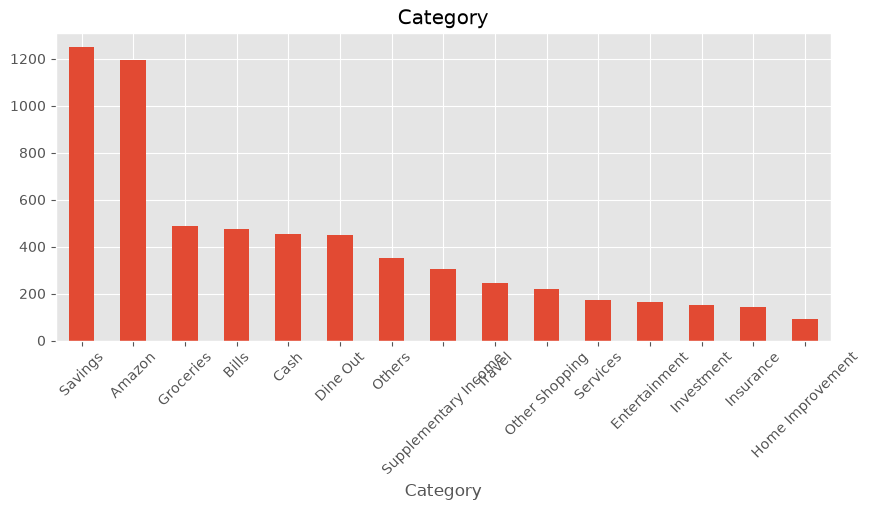

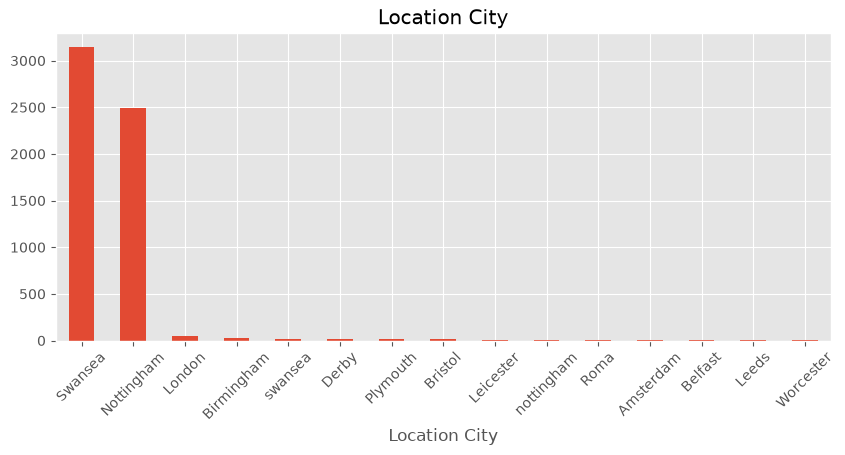

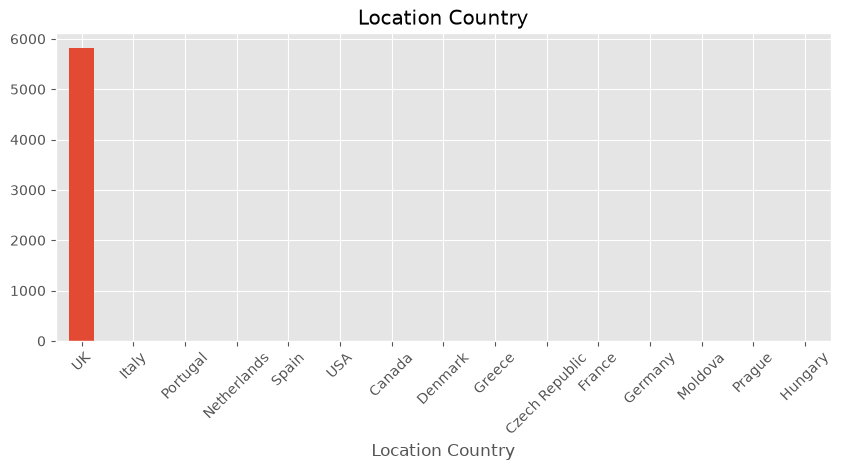

In [22]:
for col in categorical_cols:

    plt.figure(figsize=(10,4))

    (
        df[col]
        .value_counts()
        .head(15)
        .plot(kind="bar")
    )

    plt.title(col)

    plt.xticks(rotation=45)

    plt.show()

11. Correlation Analysis

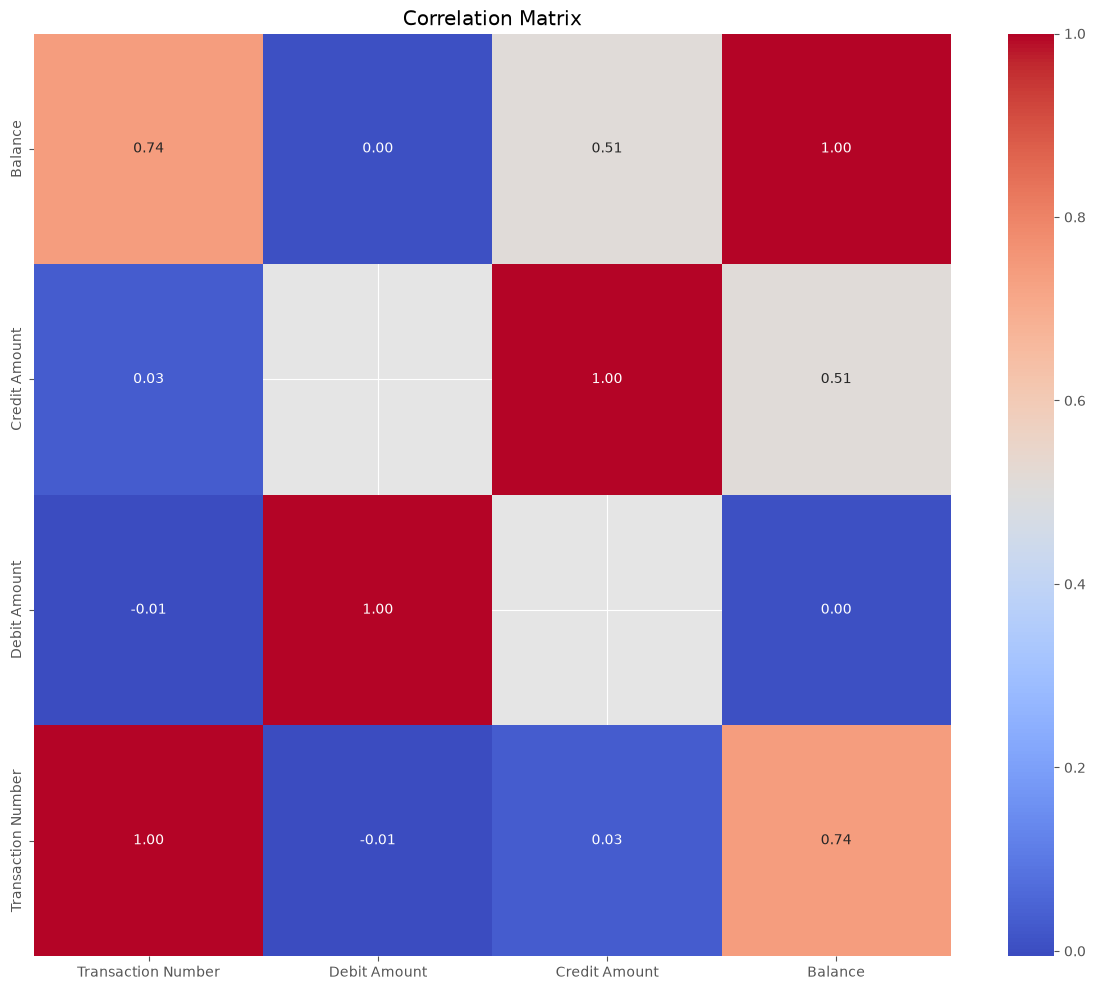

In [ ]:
numeric_cols = [
    "Transaction Number",
    "Debit Amount",
    "Credit Amount",
    "Balance",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr.loc[numeric_cols, numeric_cols],
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=numeric_cols,
    yticklabels=numeric_cols,
)

plt.gca().invert_yaxis() # Invert Y axis values for better visualizations
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Outlier Detection

In [35]:
numeric_cols

Index(['Transaction Number', 'Debit Amount', 'Credit Amount', 'Balance'], dtype='str')

In [36]:
for col in numeric_cols:

    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Transaction Number: 0 outliers
Debit Amount: 752 outliers
Credit Amount: 93 outliers
Balance: 5 outliers


Initial Findings